In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")

class SocialState(TypedDict):
    topic: str
    instagram_post: str
    twitter_post : str 
    facebook_post : str 
    final_output : str 


#generate instagram post
def generate_instagram(state:SocialState)->SocialState:
    prompt = f"""
    Generate an instagram post for the topic below.
    topic:
    {state['topic']}

    Requirements:
    - Engaging and visual language
    - 2 to 3 short paragraph (150 -200 words max)
    - Include relevenat emojis
    - End with 5-8 relevant hashtags
    - Casual, firendly tone
    - Call-to-action to engage with the post

    Make it perfect for Instagram's audience
    """
    print('generating instagram post')
    response = llm.invoke(prompt).content 
    return {
        "instagram_post":response
    }

# Generate twitter post
def generate_twitter(state:SocialState)->SocialState:
    prompt = f"""
    Generate a twitter post for the topic below.
    topic:
    {state['topic']}

    Requirements:
    - Maximum  280 characters (this is crucial)
    - Punchy and attention=grabbing
    - Including 2-3 relevant hashtags
    - Conversational tone
    - Can use emojis sparingly
    - Should spark engagement/replies

    Make it perfect for Twitter's fast-paced environment.

    """

    print('generating Twitter post')
    response = llm.invoke(prompt).content 

    return {
        "twitter_post":response
    }

#generate facebook post
def generate_facebook(state:SocialState)->SocialState:
    prompt = f"""
    Generate a facebook post for the topic below.
    topic:
    {state['topic']}

    Target audience: young professionals
    Tone: inspirational and uplifting

    Include:
    - A powerful opening line
    - A short relatable story or idea
    - Encouragement
    - A call-to-action asking readers to share their experience

    Keep it emotionally engaging.

    """

    print('generating Facebook post')
    response = llm.invoke(prompt).content 

    return {
        "facebook_post": response
    }

#merge all social media post
def generate_output(state:SocialState)->SocialState:
    output_summary = f""" 
    {'*'*50}
    SOCIAL MEDIA POST SUMMARY
    {'*'*50}

    TOPIC:
    {state['topic']}


    {'='*50}
    INSTAGRAM POST
    {'='*50}
    {state['instagram_post']}


    {'='*50}
    TWITTER POST
    {'='*50}
    {state['twitter_post']}


    {'='*50}
    FACEBOOK POST
    {'='*50}
    {state['facebook_post']}

    """
    return {
        "final_output":output_summary
    }





In [2]:
graph = StateGraph(SocialState)

graph.add_node("instagram",generate_instagram)
graph.add_node("twitter", generate_twitter)
graph.add_node("facebook", generate_facebook)
graph.add_node("final_output", generate_output)

graph.add_edge(START, "instagram")
graph.add_edge(START, "twitter")
graph.add_edge(START, "facebook")

graph.add_edge("instagram","final_output")
graph.add_edge("twitter","final_output")
graph.add_edge("facebook","final_output")

graph.add_edge("final_output", END)

app = graph.compile()


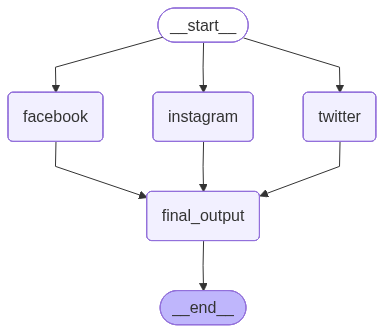

In [3]:
app

In [4]:
# execute the topic to generate posts for
result = app.invoke({
    "topic": "Lagos hustle"
})

#print out the generate results
print(result['final_output'])



generating Facebook post
generating instagram post
generating Twitter post

    Generate a twitter post for the topic below.
    topic:
    Lagos hustle

    Requirements:
    - Maximum  280 characters (this is crucial)
    - Punchy and attention=grabbing
    - Including 2-3 relevant hashtags
    - Conversational tone
    - Can use emojis sparingly
    - Should spark engagement/replies

    Make it perfect for Twitter's fast-paced environment.

    
Twitter generated
Facebook generated
instagram generated
 
    **************************************************
    SOCIAL MEDIA POST SUMMARY
    **************************************************

    TOPIC:
    Lagos hustle


    INSTAGRAM POST
    🌆✨ Welcome to the vibrant chaos of Lagos, where the hustle never sleeps! Whether you’re navigating the bustling streets of Lekki or sipping suya in Surulere, there’s an electric energy in the air that fuels every dreamer, creator, and go-getter. 🚀💪 From early morning commutes to late-night br